In [1]:
import pandas as pd 
from matplotlib import pyplot as plt
import numpy as np 
import seaborn as sbn 
import pickle as pkl
from matplotlib import cm
import torch 
import argparse
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import percentileofscore
from shutil import rmtree
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

import sys 
sys.path.append('../src/')
from utils import get_filtered_scores
from AE import AE
from NN import NN
from DVGS import DVGS
import similarities

import os

sys.path.append('../scripts/')
from run_beataml import *

/home/teddy/miniconda3/envs/dvgs/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#drug = 'Saracatinib (AZD0530)'
drug = 'Imatinib'
#drug = 'Sorafenib'

values = pd.read_csv('../results/beatAML/' + drug + '/data_values.csv')#[['source_id', 'vals_mean']]
values.head()

FileNotFoundError: [Errno 2] No such file or directory: '../results/beatAML/Imatinib/data_values.csv'

In [ ]:
NUM_MUT_FEATURES = 100

mut = pd.read_csv('../../beatAML/beataml_wes_wv1to4_mutations_dbgap.txt', sep='\t')
mut = mut[['dbgap_sample_id', 'symbol']].drop_duplicates()
genes = mut.groupby('symbol')[['dbgap_sample_id']].count().reset_index().sort_values('dbgap_sample_id', ascending=False).head(NUM_MUT_FEATURES).symbol.values
mut = mut[lambda x: x.symbol.isin(genes)]
mut = mut.pivot_table(index='dbgap_sample_id', columns='symbol', aggfunc='size', fill_value=0)

resp = pd.read_csv(f'../../beatAML/beataml_probit_curve_fits_v4_dbgap.txt', sep='\t')
drRes = resp[lambda x: (x.inhibitor == drug) & ~x.dbgap_rnaseq_sample.isna() & ~x.dbgap_dnaseq_sample.isna() & x.dbgap_rnaseq_sample.isin(values.source_id)]
drRes.head()
drRes = drRes[['dbgap_dnaseq_sample', 'dbgap_rnaseq_sample', 'inhibitor', 'auc']]

dat = mut.merge(drRes, left_on='dbgap_sample_id', right_on='dbgap_dnaseq_sample', how='inner').dropna()
dat.head()

X = dat[genes].values
y = dat.auc.values 



In [ ]:
args = argparse.Namespace() 
args.nfolds = 10
args.verbose = True
args.supervised = True
args.test_p = 0.15
args.variance_filter = None
args.zscore = False
args.pca = False
args.num_pca_comp = 25
args.use_nn = True

In [ ]:
low, high = eval(X, y, ids=dat.dbgap_rnaseq_sample.values, res=values, args=args, randomize=False)

training filtered models... progress: 9/10
training filtered models... progress: 9/10
training filtered models... progress: 9/10
training filtered models... progress: 9/10
training filtered models... progress: 9/10
training filtered models... progress: 9/10
training filtered models... progress: 9/10
training filtered models... progress: 9/10
training filtered models... progress: 9/10
training filtered models... progress: 9/10


In [ ]:
low_rand, high_rand = eval(X, y, ids=dat.dbgap_rnaseq_sample.values, res=values, args=args, randomize=True)

training filtered models... progress: 9/10
training filtered models... progress: 9/10
training filtered models... progress: 9/10
training filtered models... progress: 9/10
training filtered models... progress: 9/10
training filtered models... progress: 9/10
training filtered models... progress: 9/10
training filtered models... progress: 9/10
training filtered models... progress: 9/10
training filtered models... progress: 9/10


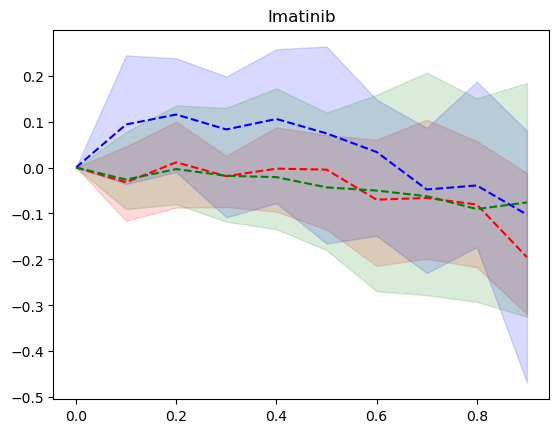

In [ ]:
'''

plt.figure()
for lows in low: 
    plt.plot(lows, 'b--')

for highs in high: 
    plt.plot(highs, 'r--')

plt.show() 


plt.figure()
for lows in low: 
    plt.plot(lows - lows[0], 'b--')

for highs in high: 
    plt.plot(highs - highs[0], 'r--')

for lows in low_rand: 
    plt.plot(lows - lows[0], 'g--')

for highs in high_rand: 
    plt.plot(highs - highs[0], 'g--')

plt.show() 
'''

qs = np.linspace(0,0.9,10)
low2 = np.array([x - x[0] for x in low])
high2 = np.array([x - x[0] for x in high])
rand2 = np.array([x - x[0] for x in high_rand] + [x - x[0] for x in low_rand])

plt.figure()
plt.title(drug)
plt.plot(qs, high2.mean(axis=0), 'r--', label='filter high')
plt.plot(qs, low2.mean(axis=0), 'b--', label='filter low')
plt.plot(qs, rand2.mean(axis=0), 'g--', label='filter random')

plt.fill_between(qs, np.quantile(high2, q=0.025, axis=0), np.quantile(high2, q=0.975, axis=0), color='r', alpha=0.15)
plt.fill_between(qs, np.quantile(low2, q=0.025, axis=0), np.quantile(low2, q=0.975, axis=0), color='b', alpha=0.15)
plt.fill_between(qs, np.quantile(rand2, q=0.025, axis=0), np.quantile(rand2, q=0.975, axis=0), color='g', alpha=0.15)
plt.show()


In [ ]:
len(os.listdir('../results/beatAML/'))

104

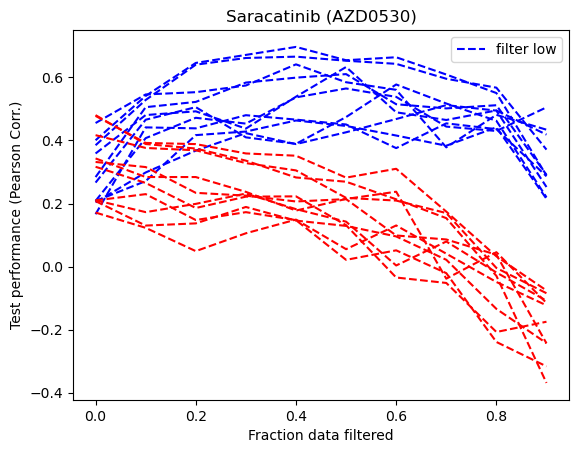

In [ ]:
perfs = pkl.load(open( '../results/beatAML/' + 'Saracatinib (AZD0530)' + '/perfs.pkl', 'rb'))
qs = np.linspace(0,0.9,10)

plt.figure()
for perf in perfs['perfs_low']: 
    plt.plot(qs, perf, 'b--')

for perf in perfs['perfs_high']: 
    plt.plot(qs, perf, 'r--')

#for perf in perfs['perfs_low_random']: 
    #plt.plot(perf, 'g--')

plt.legend(['filter low'])
plt.title('Saracatinib (AZD0530)')
plt.xlabel('Fraction data filtered')
plt.ylabel('Test performance (Pearson Corr.)')
plt.show()

mean max filter low: 0.1409869945650146


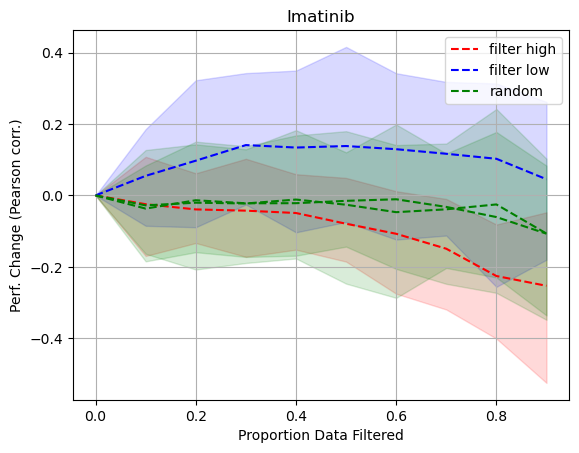

mean max filter low: 0.20449353001303755


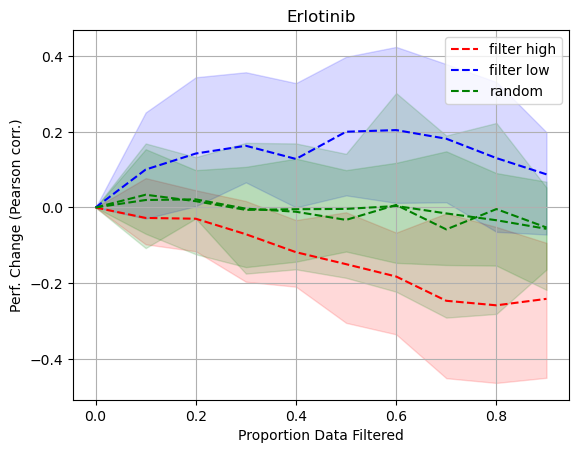

mean max filter low: 0.05972353257566236


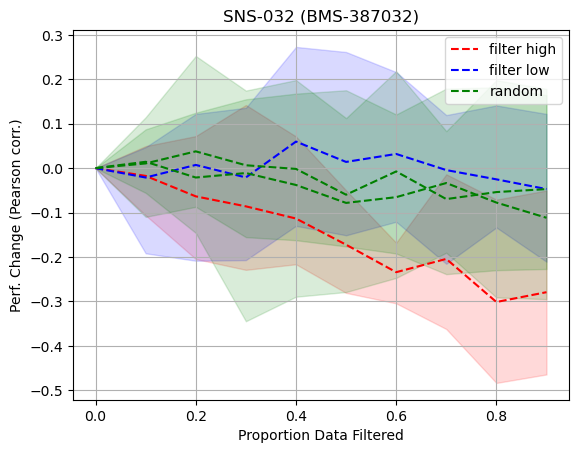

,drug,mean_perf_no_filter,max_avg_improvement_filter_low
0,Imatinib,0.172365,0.140987
1,Erlotinib,0.281696,0.204494
2,SNS-032 (BMS-387032),0.389167,0.059724


In [ ]:
res = {'drug':[], 'mean_perf_no_filter':[], 'max_avg_improvement_filter_low':[]}

for dir in os.listdir('../results/beatAML/'): 

        try: 

            perfs = pkl.load(open( '../results/beatAML/' + dir + '/perfs.pkl', 'rb'))

            low = np.array([x - x[0] for x in perfs['perfs_low']])
            high = np.array([x - x[0] for x in perfs['perfs_high']])
            low_random = np.array([x - x[0] for x in perfs['perfs_low_random']])
            high_random = np.array([x - x[0] for x in perfs['perfs_high_random']])

            print('mean max filter low:', np.max(low.mean(axis=0)))

            res['drug'].append(dir)
            res['mean_perf_no_filter'].append(np.mean([x[0] for x in perfs['perfs_low']] + [x[0] for x in perfs['perfs_high']]))
            res['max_avg_improvement_filter_low'].append(np.max(low.mean(axis=0)))
                                              
            qs = np.linspace(0., 0.9, 10)

            plt.figure()
            plt.plot(qs, high.mean(axis=0), 'r--', label='filter high')
            plt.plot(qs, low.mean(axis=0), 'b--', label='filter low')
            plt.plot(qs, high_random.mean(axis=0), 'g--', label='random')
            plt.plot(qs, low_random.mean(axis=0), 'g--')
            #plt.ylim(-1,1)

            plt.fill_between(qs, np.quantile(high, q=0.025, axis=0), np.quantile(high, q=0.975, axis=0), color='r', alpha=0.15)
            plt.fill_between(qs, np.quantile(low, q=0.025, axis=0), np.quantile(low, q=0.975, axis=0), color='b', alpha=0.15)
            plt.fill_between(qs, np.quantile(high_random, q=0.025, axis=0), np.quantile(high_random, q=0.975, axis=0), color='g', alpha=0.15)
            plt.fill_between(qs, np.quantile(low_random, q=0.025, axis=0), np.quantile(low_random, q=0.975, axis=0), color='g', alpha=0.15)

            plt.grid()
            plt.legend()

            plt.title(dir)

            plt.xlabel('Proportion Data Filtered')
            plt.ylabel('Perf. Change (Pearson corr.)')
            plt.show()
    
        except: 
            print('failed:', dir)
            #raise

res = pd.DataFrame(res)
res.head()

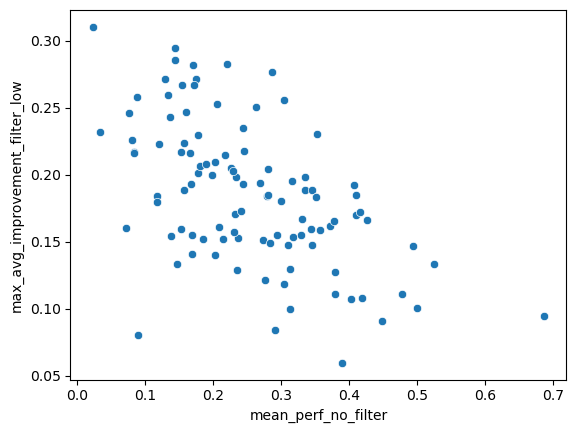

In [ ]:
plt.figure()
sbn.scatterplot(x='mean_perf_no_filter', y='max_avg_improvement_filter_low', data=res)
plt.show()

In [ ]:
res = {'drug':[], 'pval':[]}

for dir in os.listdir('../results/beatAML/'): 

    try: 

        vals = pd.read_csv('../results/beatAML/' + dir  + '/data_values.csv')[['source_id', 'vals_mean', 'vals0']]
        info = pd.read_excel('../../beatAML/beataml_wv1to4_clinical.xlsx')[['dbgap_rnaseq_sample', 'specimenType']]
        resp = pd.read_csv('../../beatAML/beataml_probit_curve_fits_v4_dbgap.txt', sep='\t')
        resp = resp[lambda x: x.inhibitor == drug][['dbgap_rnaseq_sample', 'curve_type', 'all_gt_50', 'all_lt_50', 'aic', 'deviance', 'pearson_chisq']]
        vals = vals.merge(info, left_on='source_id', right_on='dbgap_rnaseq_sample', how='left')
        vals = vals.merge(resp, left_on='source_id', right_on='dbgap_rnaseq_sample', how='left')

        xx = vals[lambda x: x.curve_type == 'increasing'].vals_mean
        yy = vals[lambda x: x.curve_type == 'decreasing'].vals_mean

        pval = ttest_ind(xx, yy, equal_var=False, alternative='less').pvalue

        res['drug'].append(dir)
        res['pval'].append(pval)

        #print(dir, pval)
        
        #plt.figure()
        #sbn.boxplot(x='specimenType', y='vals_mean', data=vals)
        #plt.show()

        if False: 
            f,axes = plt.subplots(1, 3, figsize=(3*5, 1*5))

            sbn.boxplot(x='curve_type', y='vals_mean', data=vals, ax=axes.flat[0])
            sbn.boxplot(x='all_gt_50', y='vals_mean', data=vals, ax=axes.flat[1])
            sbn.boxplot(x='all_lt_50', y='vals_mean', data=vals, ax=axes.flat[2])
            #sbn.regplot(x='aic', y='vals_mean', data=vals, ax=axes.flat[3], lowess=False)
            #sbn.regplot(x='deviance', y='vals_mean', data=vals, ax=axes.flat[4], lowess=False)
            #sbn.scatterplot(x='pearson_chisq', y='vals_mean', data=vals, ax=axes.flat[5])
            #axes.flat[2].set_xscale('log')
            plt.suptitle(dir)
            plt.tight_layout()
            plt.show()

    except: 
        print('failed', dir)


res = pd.DataFrame(res)
res.head()

failed JNJ-28312141


,drug,pval
0,Imatinib,0.445862
1,Erlotinib,0.212665
2,SNS-032 (BMS-387032),0.178639
3,Gefitinib,0.522598
4,SB-431542,0.623560


In [ ]:
res = res.assign(pval_adj = multipletests(res.pval, method='fdr_bh')[1])
res.head()

,drug,pval,pval_adj
0,Imatinib,0.445862,0.530341
1,Erlotinib,0.212665,0.353299
2,SNS-032 (BMS-387032),0.178639,0.335587
3,Gefitinib,0.522598,0.578791
4,SB-431542,0.623560,0.669028


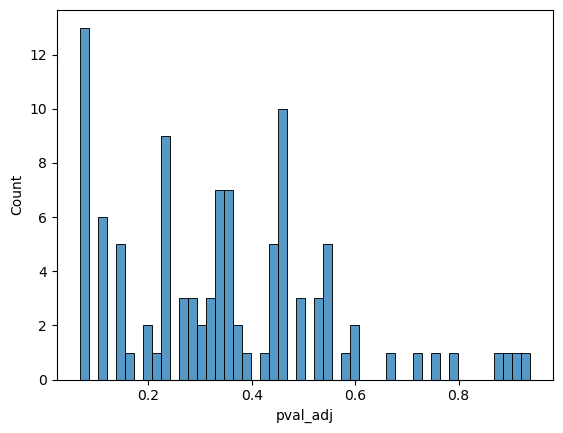

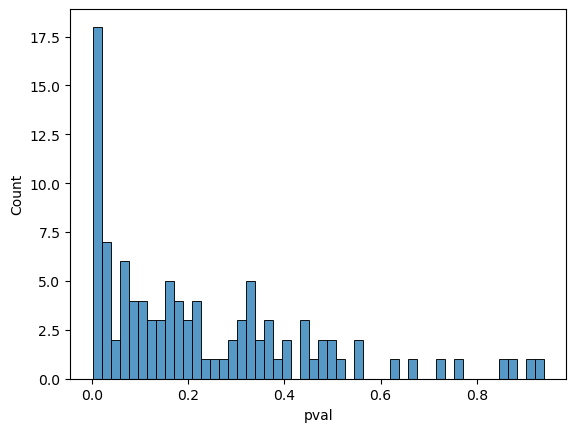

In [ ]:
plt.figure()
sbn.histplot(res.pval_adj, bins=50)
plt.show()

plt.figure()
sbn.histplot(res.pval, bins=50)
plt.show()

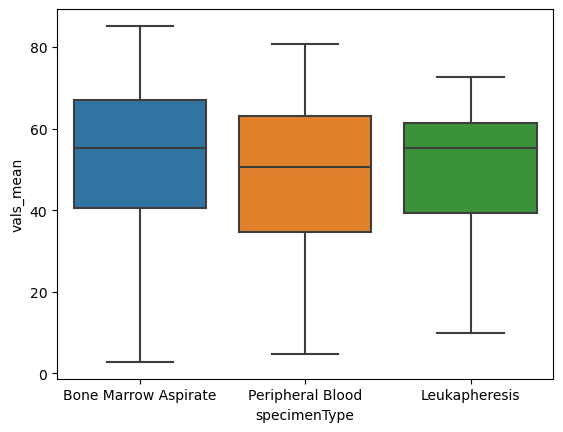

In [ ]:

plt.figure()
sbn.boxplot(x='specimenType', y='vals_mean', data=vals)
plt.show()

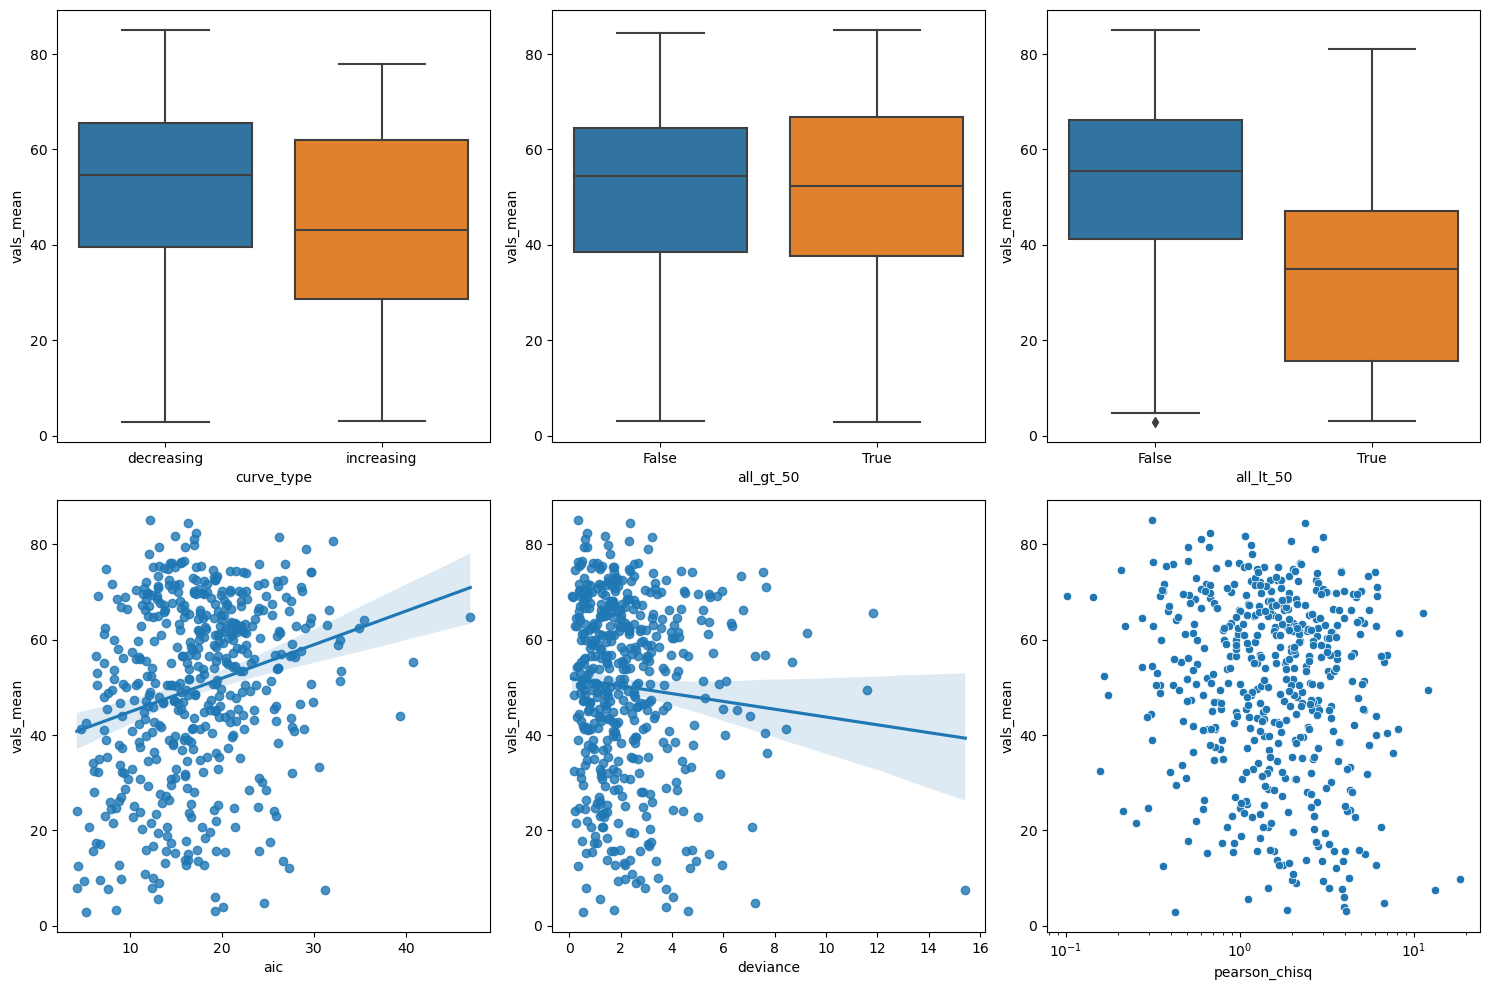

In [ ]:

f,axes = plt.subplots(2, 3, figsize=(3*5, 2*5))

sbn.boxplot(x='curve_type', y='vals_mean', data=vals, ax=axes.flat[0])
sbn.boxplot(x='all_gt_50', y='vals_mean', data=vals, ax=axes.flat[1])
sbn.boxplot(x='all_lt_50', y='vals_mean', data=vals, ax=axes.flat[2])
sbn.regplot(x='aic', y='vals_mean', data=vals, ax=axes.flat[3], lowess=False)
sbn.regplot(x='deviance', y='vals_mean', data=vals, ax=axes.flat[4], lowess=False)
sbn.scatterplot(x='pearson_chisq', y='vals_mean', data=vals, ax=axes.flat[5])
axes.flat[5].set_xscale('log')
plt.tight_layout()
plt.show()
